# Grab Stock Data

## 1. Stock Data

In [1]:
#Grab Data
import yfinance as yf

#Usual Suspects
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

# Portfolio 
symbols = [
    # Banks
    'HSBA.L',
    'BARC.L',
    'LLOY.L',

    # Insurance
    'AV.L',
    'LGEN.L',
    'PRU.L',

    # Mining
    'RIO.L',
    'AAL.L',
    'ANTO.L',

    # Healthcare
    'AZN.L',
    'GSK.L',
    'SN.L',

    # Consumer Staples
    'ULVR.L',
    'DGE.L',
    'IMB.L'
]

#Get the stock data
data = yf.download(symbols, start="2019-01-01", end="2025-12-31", auto_adjust=False)
if data is None:
    raise RuntimeError("yfinance returned no data")

data.head()

[*********************100%***********************]  15 of 15 completed


Price         Adj Close                                                   \
Ticker            AAL.L      ANTO.L        AV.L        AZN.L      BARC.L   
Date                                                                       
2019-01-02  1663.959961  768.785950  365.154907  5892.069336  150.339737   
2019-01-03  1629.131714  736.453918  360.837067  5998.871094  149.920715   
2019-01-04  1708.711060  783.953979  372.514954  6077.725098  154.749802   
2019-01-07  1722.720093  807.704285  374.183167  5993.881348  155.069046   
2019-01-08  1707.348755  811.895386  380.660004  5887.078613  156.964767   

Price                                                                      \
Ticker            DGE.L        GSK.L      HSBA.L        IMB.L      LGEN.L   
Date                                                                        
2019-01-02  2755.936523  1505.849121  644.277710  2368.403076  229.092545   
2019-01-03  2734.975586  1512.473755  639.096436  2399.723389  226.506149   
2019-01-04  2735.474609  1524.115845  654.142090  2438.500488  233.966827   
2019-01-07  2714.014404  1519.901001  639.793823  2316.699951  233.966827   
2019-01-08  2729.984619  1524.717529  646.768677  2333.602783  237.746918   

Price       ...     Volume                                                     \
Ticker      ...      DGE.L    GSK.L    HSBA.L      IMB.L    LGEN.L     LLOY.L   
Date        ...                                                                 
2019-01-02  ...  4474176.0  5892256  20316982  2563029.0  12793400  142576767   
2019-01-03  ...  4800022.0  6467863  16933833  3201776.0   9158516  146329323   
2019-01-04  ...  6936408.0  8038374  21529037  1853140.0  12237819  133867623   
2019-01-07  ...  5168667.0  7530972  21716788  3211002.0  14490681  246624166   
2019-01-08  ...  6362434.0  7302826  15291399  3046962.0  12452899  124666165   

Price                                                
Ticker         PRU.L      RIO.L       SN.L   ULVR.L  
Date                                                 
2019-01-02   7224817  4962366.0  3473865.0  1702003  
2019-01-03  11068353  3627895.0  4147585.0  1880917  
2019-01-04   8283493  4390965.0  2501318.0  1770810  
2019-01-07  13933434  4030091.0  3510334.0  1934066  
2019-01-08   6244688  3625719.0  4737663.0  1949076  

[5 rows x 90 columns]

## 2. Indice Data

In [2]:
#Import FTSE 100 data and plot cum_returns for performance comparison
ftse_index = yf.download('^FTSE', start='2019-01-01', end="2025-12-31", auto_adjust=False)
if ftse_index is None:
    raise RuntimeError("yfinance returned no FTSE 100 data")

ftse_index.head()

[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,^FTSE,^FTSE,^FTSE,^FTSE,^FTSE,^FTSE
Date,,,,,,
2019-01-02,6734.200195,6734.200195,6753.299805,6599.500000,6728.100098,614252000
2019-01-03,6692.700195,6692.700195,6753.100098,6685.100098,6734.200195,674099100
2019-01-04,6837.399902,6837.399902,6850.399902,6692.500000,6692.700195,639136700
2019-01-07,6810.899902,6810.899902,6874.100098,6778.000000,6837.399902,736559900
2019-01-08,6861.600098,6861.600098,6901.500000,6804.899902,6810.899902,651977000


# Visualise Return

In [3]:
#Visualize cumulative returns of each stock in the portfolio
if data is None:
    raise RuntimeError("Stock data is missing")

close_prices = data["Adj Close"]
portfolio_returns = close_prices.pct_change().dropna()

port_comps_rets_cumprod = ((portfolio_returns + 1).cumprod() - 1) * 100

#Plot
fig = px.line(port_comps_rets_cumprod, x=port_comps_rets_cumprod.index, y=port_comps_rets_cumprod.columns, title='Cumulative Returns of Portfolio Stocks (2019-2025)')

fig.update_xaxes(title_text='Date')
fig.update_yaxes(title_text='Cumulative Return in %')

fig.show()


# Optimization

## 1. Train Test Split Data

In [4]:
from pypfopt import risk_models, expected_returns
from pypfopt.expected_returns import ema_historical_return
from pypfopt.risk_models import exp_cov
from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt.plotting import plot_efficient_frontier
from pypfopt.plotting import plot_weights
from pypfopt.cla import CLA

#Train Test Split the Data
train = portfolio_returns["2019-01-01":"2023-12-31"]
test = portfolio_returns["2024-01-01":"2025-12-31"]

#Get mu and Sigma from expected_returns and risk
mu = expected_returns.ema_historical_return(train, returns_data = True, span = 500)
Sigma = risk_models.exp_cov(train, returns_data = True, span = 180)


## 2. Efficient Frontier

Text(0.5, 1.0, 'Efficient Frontier')

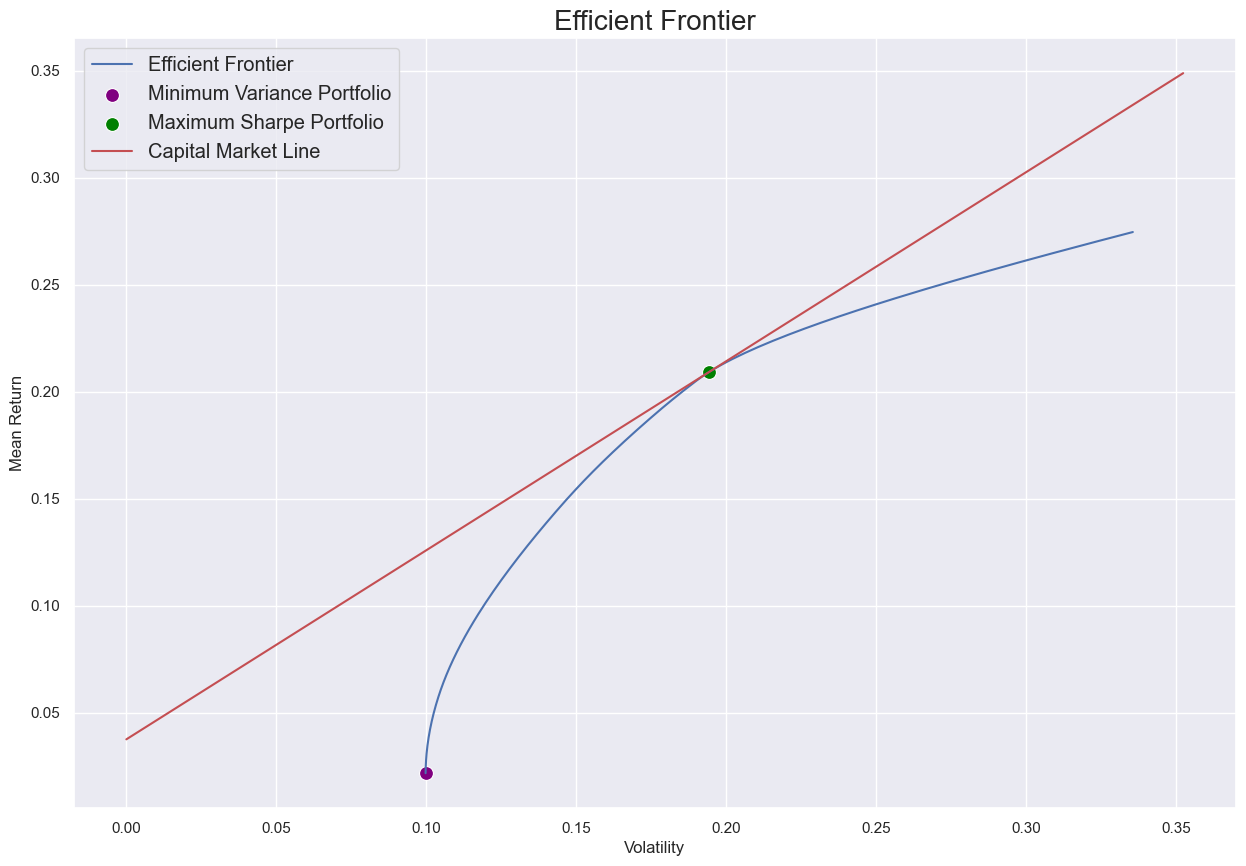

In [10]:
#For visual purposes and calculate efficient frontier
from numbers import Real


def as_real_float(value: object, label: str) -> float:
    if value is None or not isinstance(value, Real):
        raise RuntimeError(f"{label} is not a valid numeric value")
    return float(value)


rf = 0.0375
solver = "SCS"
solver_options = {"max_iters": 300000, "eps": 1e-6}

# Build frontier with CLA for better numerical stability
cla = CLA(mu, Sigma)
ret_ef_raw, vol_ef_raw, _ = cla.efficient_frontier(points=500)
ret_ef = [as_real_float(v, "Frontier return") for v in ret_ef_raw]
vol_ef = [as_real_float(v, "Frontier volatility") for v in vol_ef_raw]

#Calculate the minimum volatility
ef = EfficientFrontier(mu, Sigma, solver=solver, solver_options=solver_options)
ef.min_volatility()
min_perf = ef.portfolio_performance(risk_free_rate=rf)
min_vol_ret = as_real_float(min_perf[0], "Minimum-variance return")
min_vol_vol = as_real_float(min_perf[1], "Minimum-variance volatility")

#Calculate the maximum sharpe ratio
ef = EfficientFrontier(mu, Sigma, solver=solver, solver_options=solver_options)
ef.max_sharpe(risk_free_rate=rf)
max_perf = ef.portfolio_performance(risk_free_rate=rf)
max_sharpe_ret = as_real_float(max_perf[0], "Max-Sharpe return")
max_sharpe_vol = as_real_float(max_perf[1], "Max-Sharpe volatility")

#Plot
sns.set_theme()

fig, ax = plt.subplots(figsize = [15,10])

sns.lineplot(x=vol_ef, y=ret_ef, label="Efficient Frontier", ax=ax)
sns.scatterplot(x=[min_vol_vol], y=[min_vol_ret], ax=ax, label="Minimum Variance Portfolio", color="purple", s=100)
sns.scatterplot(x=[max_sharpe_vol], y=[max_sharpe_ret], ax=ax, label="Maximum Sharpe Portfolio", color="green", s=100)

x_cml_max = max(vol_ef) * 1.05
y_cml_max = rf + ((max_sharpe_ret - rf) / max_sharpe_vol) * x_cml_max
sns.lineplot(x=[0.0, x_cml_max], y=[rf, y_cml_max], label="Capital Market Line", ax=ax, color="r")

ax.set_xlabel("Volatility")
ax.set_ylabel("Mean Return")
plt.legend(fontsize='large')
plt.title("Efficient Frontier", fontsize='20')


# Weights

## 1. Minimum Variance

Expected annual return: 2.2%
Annual volatility: 10.0%
Sharpe Ratio: -0.16


(np.float64(0.021691590190416516),
 np.float64(0.09974645649772435),
 np.float64(-0.15848592887050722))

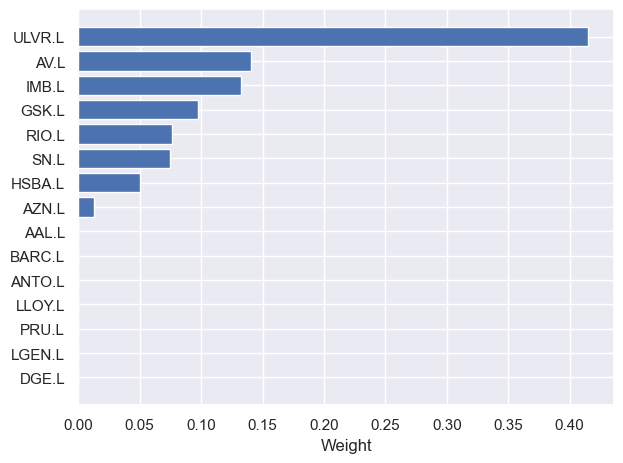

In [6]:
# Minimum Variance
ef = EfficientFrontier(mu, Sigma, solver="SCS", solver_options={"max_iters": 300000, "eps": 1e-6})
raw_weights_minvar_exp = ef.min_volatility()

plot_weights(raw_weights_minvar_exp)
ef.portfolio_performance(verbose = True, risk_free_rate = 0.0375)


## 2. Maximum Sharpe

Expected annual return: 20.9%
Annual volatility: 19.4%
Sharpe Ratio: 0.88


(np.float64(0.20900423112590297),
 np.float64(0.19406290183370514),
 np.float64(0.8837558827851962))

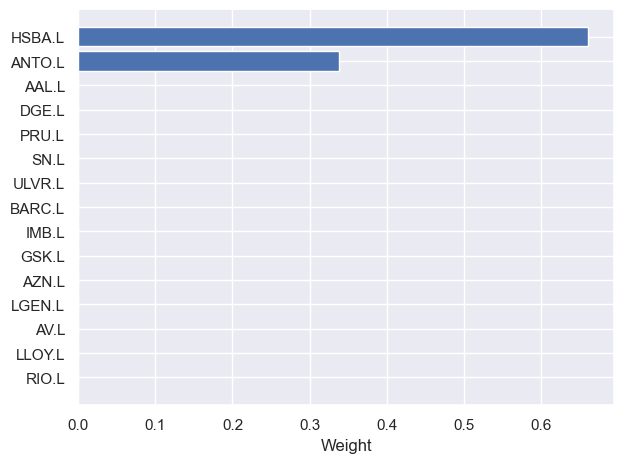

In [7]:
# Maximum Sharpe
ef = EfficientFrontier(mu, Sigma, solver="SCS", solver_options={"max_iters": 300000, "eps": 1e-6})
raw_weights_maxsharpe_exp = ef.max_sharpe(risk_free_rate=0.0375)

plot_weights(raw_weights_maxsharpe_exp)
ef.portfolio_performance(verbose = True, risk_free_rate = 0.0375)


# Backtesting

In [8]:
#List the weights of each portfolio mix & set them into variables
weights_minvar_exp = list(raw_weights_minvar_exp.values())
weights_maxsharpe_exp = list(raw_weights_maxsharpe_exp.values())

ret_1 = ((test.dot(weights_minvar_exp) + 1).cumprod() - 1) * 100
ret_2 = ((test.dot(weights_maxsharpe_exp) + 1).cumprod() - 1) * 100

#Include the FTSE 100 for returns comparison
if ftse_index is None:
    raise RuntimeError("FTSE 100 data is missing")
ftse_close = ftse_index.loc["2024-01-01":"2025-12-31", "Adj Close"]
ind_ret = ((ftse_close.pct_change() + 1).cumprod() - 1) * 100

#Set everything into a dataframe
back = pd.DataFrame({"MinVar":ret_1, "MaxSharpe":ret_2})
back = pd.concat([back, ind_ret],  join = "outer", axis = 1, sort = True)
back.drop(back.tail(1).index,inplace=True)

back.interpolate(method = "linear", inplace = True)

#Plot
fig = px.line(back, x = back.index, y = back.columns, title = "Portfolio Performance")
fig.update_xaxes(title_text='Date')
fig.update_yaxes(title_text='Cumulative Return in %')

fig.show()
